[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[1.38879439e-11 6.00148563e-11 2.47999945e-10 ... 2.83364720e-82
  4.73449499e-84 7.55581902e-86]
 [1.38879439e-11 6.00148563e-11 2.47999945e-10 ... 2.83364720e-82
  4.73449499e-84 7.55581902e-86]
 [1.38879439e-11 6.00148563e-11 2.47999945e-10 ... 2.83364720e-82
  4.73449499e-84 7.55581902e-86]
 ...
 [1.38879439e-11 6.00148563e-11 2.47999945e-10 ... 2.83364720e-82
  4.73449499e-84 7.55581902e-86]
 [1.38879439e-11 6.00148563e-11 2.47999945e-10 ... 2.83364720e-82
  4.73449499e-84 7.55581902e-86]
 [1.38879439e-11 6.00148563e-11 2.47999945e-10 ... 2.83364720e-82
  4.73449499e-84 7.55581902e-86]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[1.38879439e-11 6.00148563e-11 2.47999945e-10 ... 2.83364720e-82
  4.73449499e-84 7.555

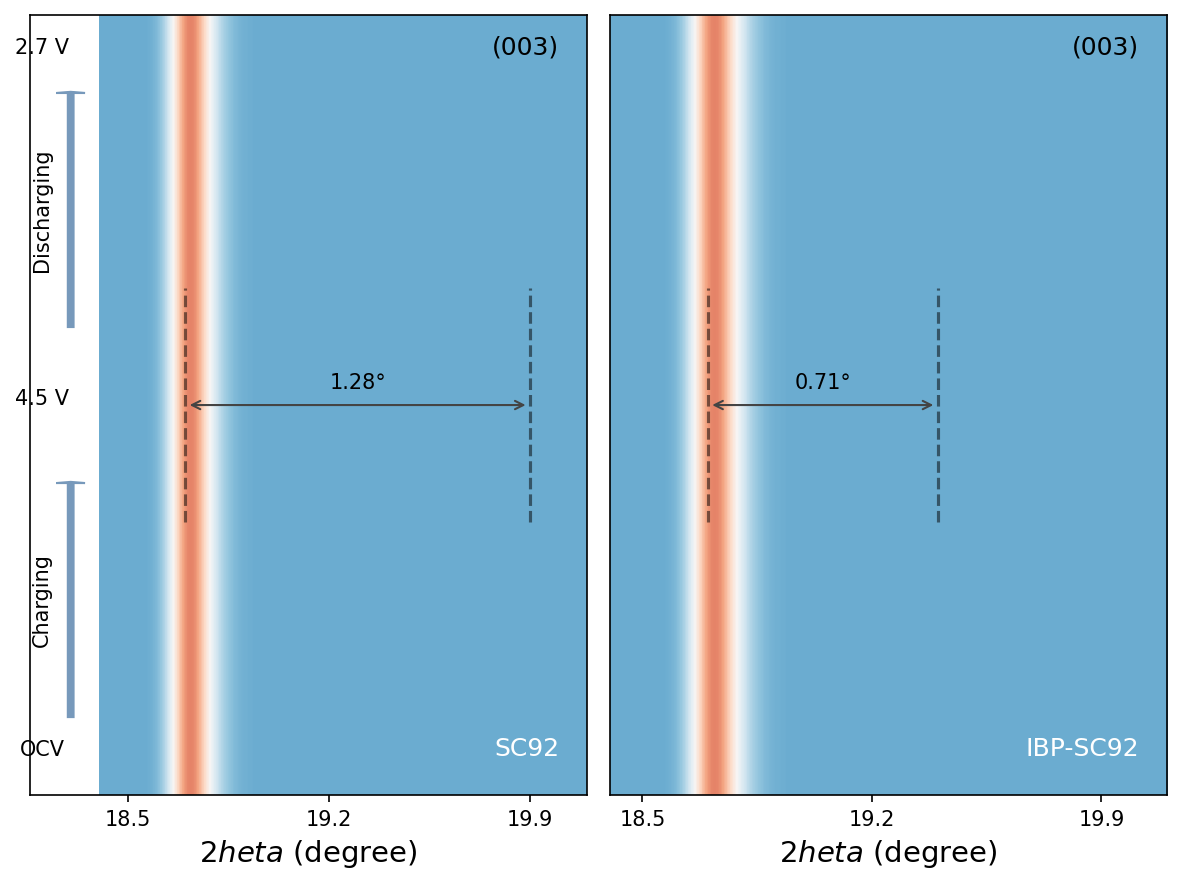

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
# Y-axis: State of Charge (Steps)
steps = np.linspace(0, 100, 200)
# X-axis: 2 Theta
two_theta = np.linspace(18.4, 20.1, 200)
TT, S = np.meshgrid(two_theta, steps)

# Function to generate the ridge path
def ridge_path(s, split_point=50, shift_mag=1.0):
    # s is 0 to 100
    # 0 -> 50: Charging (Shift right then abrupt left?)
    # Based on image:
    # Starts at ~18.9
    # Shifts to ~18.7 (lower angle)
    # Then jumps to ~19.9 (high angle) at top of charge

    center = np.ones_like(s) * 18.9

    # Lower half (Charging)
    mask_low = s < 50
    # Parabolic shift left
    center[mask_low] = 18.9 - 0.2 * np.sin(np.pi * s[mask_low] / 50)

    # Upper half (Discharging) - Mirror?
    mask_high = s >= 50
    center[mask_high] = 18.7 + 0.2 * np.sin(np.pi * (s[mask_high]-50) / 50)

    # The Split/Jump part (High Voltage Phase)
    # At s ~ 40-60, there is a second peak at higher angle
    center2 = np.ones_like(s) * np.nan
    mask_split = (s > 35) & (s < 65)
    # Grows from 19.5 to 19.9 then back?
    center2[mask_split] = 19.5 + 0.4 * np.sin(np.pi * (s[mask_split]-35)/30)

    return center, center2

# Generate Intensity Z
def generate_z(tt, s, path1, path2, width=0.1):
    z = np.zeros_like(tt)
    # Path 1
    z += np.exp(-((tt - path1)/width)**2)
    # Path 2
    mask = ~np.isnan(path2)
    # z[mask] += 0.8 * np.exp(-((tt[mask] - path2[mask])/width)**2)
    return z

# SC92 (Left) - Large Shift
p1_sc, p2_sc = ridge_path(steps, shift_mag=1.2)
# Modify p2_sc to go further right
mask_split = (steps > 35) & (steps < 65)
p2_sc[mask_split] = 19.3 + 0.6 * np.sin(np.pi * (steps[mask_split]-35)/30) # Max ~19.9

Z_sc = generate_z(TT, S, p1_sc, p2_sc)

# IBP-SC92 (Right) - Smaller Shift
p1_ibp, p2_ibp = ridge_path(steps) # Base path
# Modify p2_ibp to shift less
p2_ibp[mask_split] = 19.1 + 0.3 * np.sin(np.pi * (steps[mask_split]-35)/30) # Max ~19.4

Z_ibp = generate_z(TT, S, p1_ibp, p2_ibp)


# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(8, 6), dpi=150, sharey=True)

# Custom Colormap for 3D effect (Blue to White to Red)
# Or just standard RdBu_r
cmap = plt.cm.RdBu_r

# Plot SC92
axes[0].imshow(Z_sc, aspect='auto', extent=[18.4, 20.1, 0, 100], cmap=cmap, vmin=-0.5, vmax=1.5)
axes[0].text(0.95, 0.05, 'SC92', transform=axes[0].transAxes, color='white', ha='right', fontsize=12)
axes[0].text(0.95, 0.95, '(003)', transform=axes[0].transAxes, color='black', ha='right', fontsize=12)

# Annotations SC92
axes[0].plot([18.7, 18.7], [35, 65], 'k--', alpha=0.5) # Left marker
axes[0].plot([19.9, 19.9], [35, 65], 'k--', alpha=0.5) # Right marker (approx)
axes[0].annotate('', xy=(18.7, 50), xytext=(19.9, 50), arrowprops=dict(arrowstyle='<->', color='#444444'))
axes[0].text(19.3, 52, '1.28°', ha='center', fontsize=10)


# Plot IBP-SC92
axes[1].imshow(Z_ibp, aspect='auto', extent=[18.4, 20.1, 0, 100], cmap=cmap, vmin=-0.5, vmax=1.5)
axes[1].text(0.95, 0.05, 'IBP-SC92', transform=axes[1].transAxes, color='white', ha='right', fontsize=12)
axes[1].text(0.95, 0.95, '(003)', transform=axes[1].transAxes, color='black', ha='right', fontsize=12)

# Annotations IBP
axes[1].plot([18.7, 18.7], [35, 65], 'k--', alpha=0.5)
axes[1].plot([19.4, 19.4], [35, 65], 'k--', alpha=0.5)
axes[1].annotate('', xy=(18.7, 50), xytext=(19.4, 50), arrowprops=dict(arrowstyle='<->', color='#444444'))
axes[1].text(19.05, 52, '0.71°', ha='center', fontsize=10)


# Y Axis Labels (Arrows)
axes[0].set_yticks([])
# Draw arrows manually
axes[0].arrow(18.3, 10, 0, 30, clip_on=False, width=0.02, head_width=0.1, color='#7799BB')
axes[0].text(18.2, 25, 'Charging', rotation=90, ha='center', va='center')
axes[0].arrow(18.3, 60, 0, 30, clip_on=False, width=0.02, head_width=0.1, color='#7799BB')
axes[0].text(18.2, 75, 'Discharging', rotation=90, ha='center', va='center')
axes[0].text(18.2, 5, 'OCV', ha='center')
axes[0].text(18.2, 50, '4.5 V', ha='center')
axes[0].text(18.2, 95, '2.7 V', ha='center')

# X Labels
for ax in axes:
    ax.set_xlabel(r'2$	heta$ (degree)', fontsize=14)
    ax.set_xticks([18.5, 19.2, 19.9])

plt.tight_layout()
plt.show()


C:\Users\julia\AppData\Local\Temp\ipykernel_18124\1686954496.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


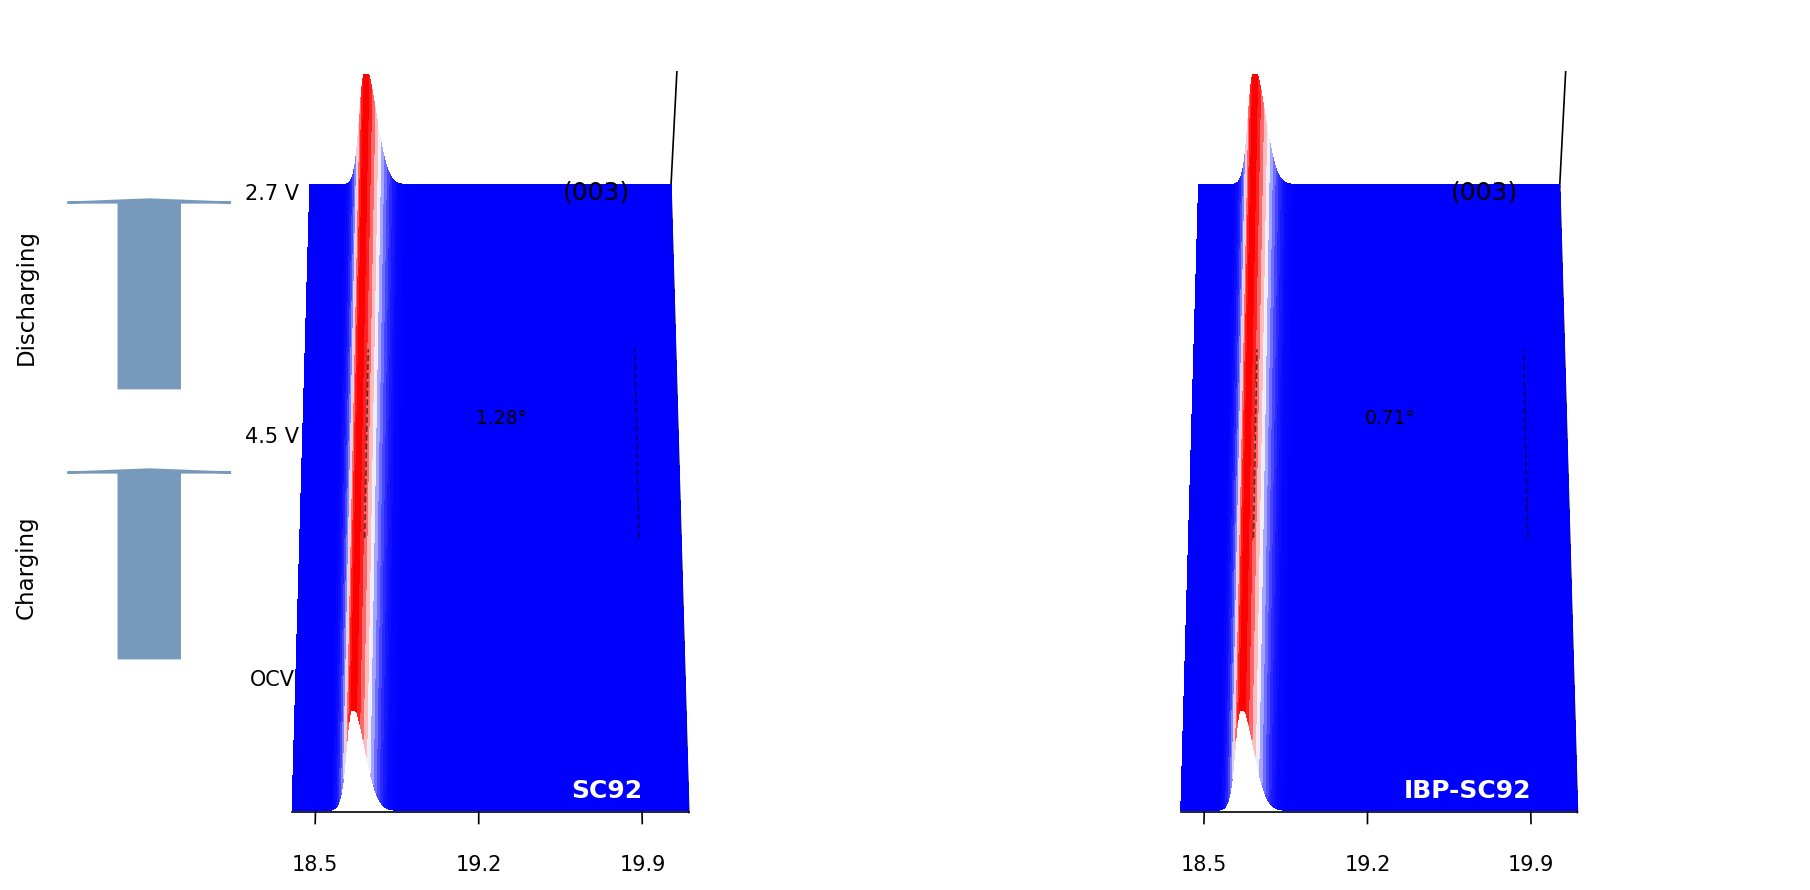

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
# Y-axis: State of Charge (Steps)
steps = np.linspace(0, 100, 300) # Higher res for smooth surface
# X-axis: 2 Theta
two_theta = np.linspace(18.4, 20.1, 300)
TT, S = np.meshgrid(two_theta, steps)

# Function to generate the ridge path
def ridge_path(s):
    center = np.ones_like(s) * 18.9

    # Lower half (Charging)
    mask_low = s < 50
    center[mask_low] = 18.9 - 0.25 * np.sin(np.pi * s[mask_low] / 50)

    # Upper half (Discharging)
    mask_high = s >= 50
    center[mask_high] = 18.7 + 0.2 * np.sin(np.pi * (s[mask_high]-50) / 50)

    # The Split/Jump part (High Voltage Phase)
    center2 = np.ones_like(s) * np.nan
    mask_split = (s > 35) & (s < 65)
    center2[mask_split] = 19.5 + 0.45 * np.sin(np.pi * (s[mask_split]-35)/30)

    return center, center2

# Generate Intensity Z
def generate_z(tt, s, path1, path2, width=0.08):
    z = np.zeros_like(tt)
    # Base background noise/blue level
    z += 0.05

    # Path 1
    z += 1.2 * np.exp(-((tt - path1)/width)**2)
    # Path 2
    mask = ~np.isnan(path2)
    # z[mask] += 0.9 * np.exp(-((tt[mask] - path2[mask])/width)**2)

    # Normalize Z to 0-1 range for colormap
    z = np.clip(z, 0, 1.2)
    return z

# SC92 (Left)
p1_sc, p2_sc = ridge_path(steps)
# Make separation wider for SC92
mask_split = (steps > 35) & (steps < 65)
p2_sc[mask_split] = 19.5 + 0.5 * np.sin(np.pi * (steps[mask_split]-35)/30)
Z_sc = generate_z(TT, S, p1_sc, p2_sc)

# IBP-SC92 (Right)
p1_ibp, p2_ibp = ridge_path(steps)
# Make separation narrower
p2_ibp[mask_split] = 19.2 + 0.25 * np.sin(np.pi * (steps[mask_split]-35)/30)
Z_ibp = generate_z(TT, S, p1_ibp, p2_ibp)


# --- Plotting ---
fig = plt.figure(figsize=(12, 6), dpi=150)

# Common settings
elev = 55
azim = -90

def style_3d_ax(ax, z_data, title, split_width_text):
    # Plot Surface
    # bwr: Blue-White-Red.
    surf = ax.plot_surface(TT, S, z_data, cmap='bwr',
                           linewidth=0, antialiased=False,
                           rstride=2, cstride=2, shade=True, lightsource=None)

    # View Angle
    ax.view_init(elev=elev, azim=azim)
    ax.set_box_aspect((1, 2, 0.5)) # Stretch Y

    # Remove Panes & Grid
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('w')
    ax.yaxis.pane.set_edgecolor('w')
    ax.zaxis.pane.set_edgecolor('w')
    ax.grid(False)

    # Hide Z axis
    ax.set_zticks([])

    # Limits
    ax.set_xlim(18.4, 20.1)
    ax.set_ylim(0, 100)

    # X Labels
    ax.set_xlabel(r'2$	heta$ (degree)', fontsize=12, labelpad=5)
    ax.set_xticks([18.5, 19.2, 19.9])

    # Y Labels (Hidden)
    ax.set_yticks([])

    # Annotations
    ax.text(19.9, 0, 0.2, title, fontsize=12, color='white', ha='right', fontweight='bold')
    ax.text(19.9, 95, 0.2, '(003)', fontsize=12, color='black', ha='right')

    # Measurement Lines
    y_pos = 50
    x1 = 18.7
    x2 = 19.9 if 'SC92' in title else 19.41

    ax.plot([x1, x1], [35, 65], [0.5, 0.5], 'k--', lw=0.8, alpha=0.6, zorder=10)
    ax.plot([x2, x2], [35, 65], [0.5, 0.5], 'k--', lw=0.8, alpha=0.6, zorder=10)
    ax.plot([x1, x2], [y_pos, y_pos], [0.5, 0.5], color='#444444', lw=1, marker='|', markersize=5)
    mid = (x1 + x2) / 2
    ax.text(mid, y_pos, 0.7, split_width_text, ha='center', fontsize=9, color='black', zorder=20)


# Subplot 1
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
style_3d_ax(ax1, Z_sc, 'SC92', '1.28°')

# Subplot 2
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
style_3d_ax(ax2, Z_ibp, 'IBP-SC92', '0.71°')

# 2D Guide Arrows
ax_guide = fig.add_axes([0.02, 0.2, 0.1, 0.6])
ax_guide.axis('off')
ax_guide.set_ylim(0, 100)
ax_guide.arrow(0.5, 10, 0, 35, width=0.15, head_width=0.4, color='#7799BB', length_includes_head=True)
ax_guide.text(0.2, 27, 'Charging', rotation=90, va='center', ha='center', fontsize=11)
ax_guide.arrow(0.5, 60, 0, 35, width=0.15, head_width=0.4, color='#7799BB', length_includes_head=True)
ax_guide.text(0.2, 77, 'Discharging', rotation=90, va='center', ha='center', fontsize=11)
ax_guide.text(0.8, 5, 'OCV', ha='center', fontsize=10)
ax_guide.text(0.8, 50, '4.5 V', ha='center', fontsize=10)
ax_guide.text(0.8, 95, '2.7 V', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


C:\Users\julia\AppData\Local\Temp\ipykernel_18124\660869799.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


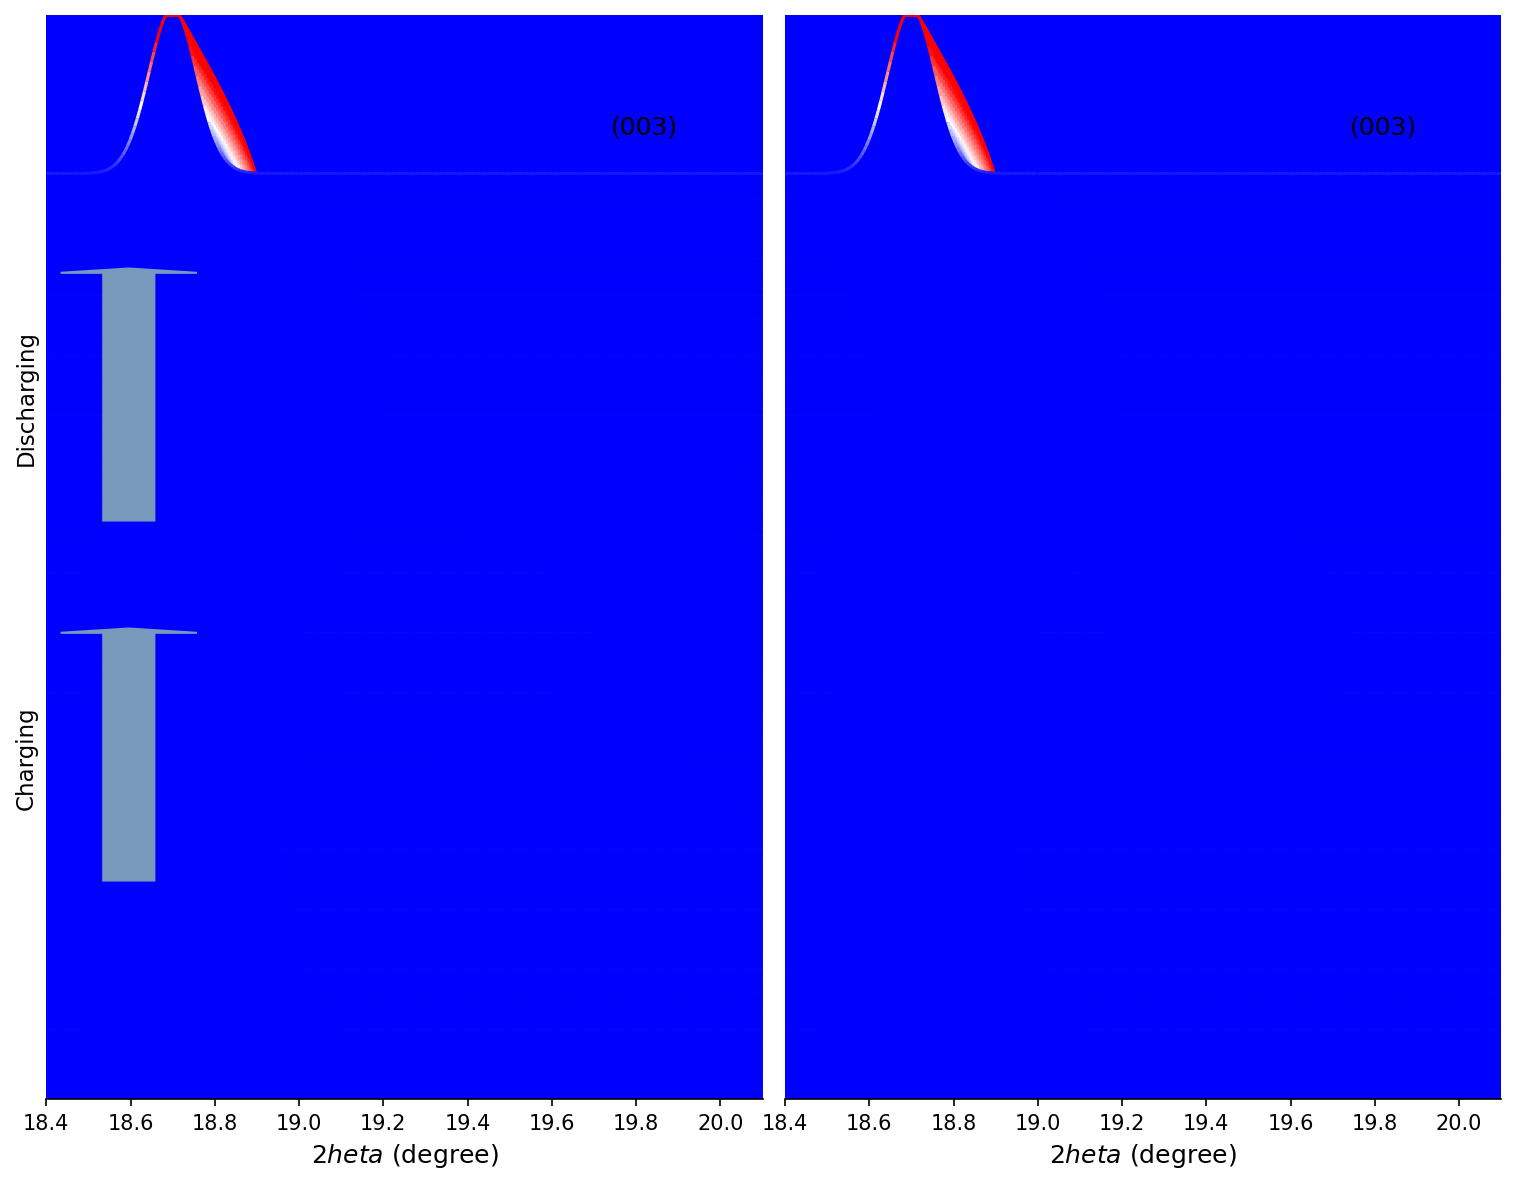

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

# --- Data Simulation (Same as before) ---
steps = np.linspace(0, 100, 200) # Slightly lower res for performance
two_theta = np.linspace(18.4, 20.1, 300)
TT, S = np.meshgrid(two_theta, steps)

def ridge_path(s):
    center = np.ones_like(s) * 18.9
    mask_low = s < 50
    center[mask_low] = 18.9 - 0.25 * np.sin(np.pi * s[mask_low] / 50)
    mask_high = s >= 50
    center[mask_high] = 18.7 + 0.2 * np.sin(np.pi * (s[mask_high]-50) / 50)
    center2 = np.ones_like(s) * np.nan
    mask_split = (s > 35) & (s < 65)
    center2[mask_split] = 19.5 + 0.45 * np.sin(np.pi * (s[mask_split]-35)/30)
    return center, center2

def generate_z(tt, s, path1, path2, width=0.08):
    z = np.zeros_like(tt)
    z += 0.05

    # Reshape paths to (N, 1) for broadcasting against (N, M)
    p1 = path1[:, np.newaxis]
    p2 = path2[:, np.newaxis]

    # Path 1
    z += 1.2 * np.exp(-((tt - p1)/width)**2)
    # Path 2
    mask = ~np.isnan(p2)
    # Since p2 has NaNs, we handle mask carefully
    # But np.exp works fine with NaNs (returns NaNs)
    z2 = 0.9 * np.exp(-((tt - p2)/width)**2)
    z += np.nan_to_num(z2)

    z = np.clip(z, 0, 1.2)
    return z

p1_sc, p2_sc = ridge_path(steps)
mask_split = (steps > 35) & (steps < 65)
p2_sc[mask_split] = 19.5 + 0.5 * np.sin(np.pi * (steps[mask_split]-35)/30)
Z_sc = generate_z(TT, S, p1_sc, p2_sc)

p1_ibp, p2_ibp = ridge_path(steps)
p2_ibp[mask_split] = 19.2 + 0.25 * np.sin(np.pi * (steps[mask_split]-35)/30)
Z_ibp = generate_z(TT, S, p1_ibp, p2_ibp)

# --- Helper: Multicolored Line ---
def plot_colored_line(ax, x, y, c, cmap='bwr', lw=1.5, zorder=1):
    # Create a set of line segments so that we can color them individually
    # This creates the points as a N x 1 x 2 array so that we can stack points
    # together easily to get the segments. The segments array for line collection
    # needs to be (numlines) x (points per line) x 2 (for x and y)
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Create a continuous norm to map from data points to colors
    norm = plt.Normalize(0.0, 1.0) # Z is 0-1.2, but we want Blue at 0.0, Red at 1.0
    lc = LineCollection(segments, cmap=cmap, norm=norm, zorder=zorder)

    # Set the values used for colormapping
    lc.set_array(c)
    lc.set_linewidth(lw)
    line = ax.add_collection(lc)
    return line

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(10, 8), dpi=150, sharey=True)

# Define Scale for Z height
# We want peaks to overlap significantly
# Step spacing is 100/200 = 0.5 units per step.
# Z max is 1.2.
# If scale is 10, Z_visual max is 12.
# This covers ~24 steps. Good overlap.
z_scale = 15

# Iterate Back to Front (Top to Bottom)
# steps are 0..100.
# We want "Top" (100) to be in Back. "Bottom" (0) in Front.
# Standard plot: Back is drawn first.
# So iterate i from len(steps)-1 down to 0.

def plot_ridge(ax, Z_data, title, split_text):
    # Set Background Color of Axis to Blue-ish?
    # No, the figure has Blue background.
    # We can set ax.set_facecolor('#445577')?
    # But bwr colormap has Blue at 0.
    # If we fill with White, we hide the blue background.
    # Let's fill with the *Background Color* of the plot, which should be the "Low Z" color.
    # bwr(0) is Blue.
    bg_color = plt.cm.bwr(0.0)
    ax.set_facecolor(bg_color)

    # Loop
    for i in range(len(steps)-1, -1, -1):
        y_base = steps[i]
        z_row = Z_data[i, :]
        y_curve = y_base + z_row * z_scale

        # 1. Fill to hide behind
        # We fill from y_curve down to... y_base?
        # If we fill down to y_base, we hide the line *at* y_base from the previous iteration?
        # No, previous iteration (Back) is already drawn.
        # We are drawing Front on top of Back.
        # So we hide what is *behind* this current curve.
        # Filling with 'white' makes it look like snowy mountains.
        # Filling with 'bg_color' makes it look like the mountain rises from the sea.
        # But if we fill with bg_color, we hide the *peaks* behind us. Correct.
        ax.fill_between(two_theta, y_base, y_curve, facecolor=bg_color, zorder=i)

        # 2. Draw the Line with Gradient
        # But plot_colored_line is slow if called 200 times.
        # Let's try simple plot first? No, we need gradient.
        # Optimize: downsample?
        plot_colored_line(ax, two_theta, y_curve, z_row, zorder=i+0.1, lw=1.5)

    ax.set_ylim(0, 100 + 1.2 * z_scale)
    ax.set_xlim(18.4, 20.1)
    ax.set_xlabel(r'2$	heta$ (degree)', fontsize=12)

    # Remove ticks/spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.get_yaxis().set_ticks([])

    # Title
    ax.text(19.9, 10, title, color='white', ha='right', fontsize=12, fontweight='bold', transform=ax.transData)
    ax.text(19.9, 105, '(003)', color='black', ha='right', fontsize=12, transform=ax.transData)

    # Annotations
    y_mark = 50 + 0.6 * z_scale # Approx height of peak at step 50
    x1 = 18.7
    x2 = 19.9 if 'SC92' in title else 19.41

    # We need to project the Z-shift into Y?
    # The dashed lines in the figure are vertical (constant Theta).
    ax.vlines(x1, 35 + 0.6*z_scale, 65 + 0.6*z_scale, colors='k', linestyles='--', alpha=0.5)
    ax.vlines(x2, 35 + 0.6*z_scale, 65 + 0.6*z_scale, colors='k', linestyles='--', alpha=0.5)

    ax.text((x1+x2)/2, y_mark + 5, split_text, ha='center', fontsize=9)
    ax.annotate('', xy=(x1, y_mark), xytext=(x2, y_mark), arrowprops=dict(arrowstyle='<->', color='black'))


plot_ridge(axes[0], Z_sc, 'SC92', '1.28°')
plot_ridge(axes[1], Z_ibp, 'IBP-SC92', '0.71°')

# Guide Arrows (2D)
ax_guide = fig.add_axes([0.02, 0.2, 0.1, 0.6])
ax_guide.axis('off')
ax_guide.set_ylim(0, 100)
ax_guide.arrow(0.5, 10, 0, 35, width=0.15, head_width=0.4, color='#7799BB', length_includes_head=True)
ax_guide.text(0.2, 27, 'Charging', rotation=90, va='center', ha='center', fontsize=11)
ax_guide.arrow(0.5, 60, 0, 35, width=0.15, head_width=0.4, color='#7799BB', length_includes_head=True)
ax_guide.text(0.2, 77, 'Discharging', rotation=90, va='center', ha='center', fontsize=11)

plt.tight_layout()
